在 metrics_main.csv 中找到的相关方法： ['Fused3-RA', 'Fused3-Blend-eta0.30']


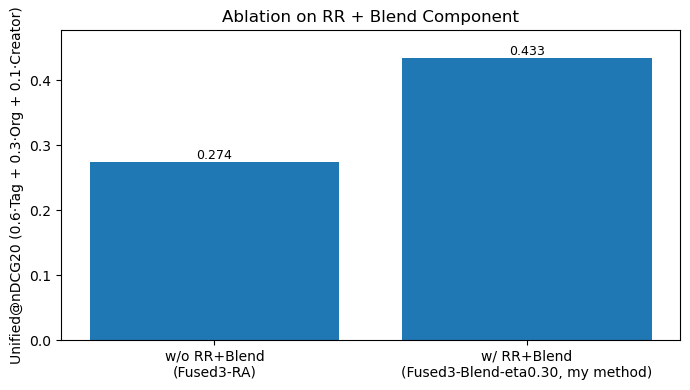


当前用于 RR+Blend 消融的行：


,method,Unified@nDCG20,Unified_cov@nDCG20,Tag-nDCG@20,Org-nDCG@20,Creator-nDCG@20,Tag-Coverage,Org-Coverage,Creator-Coverage
0,Fused3-RA,0.274320,0.092274,0.109729,0.417277,0.832993,0.411291,0.004504,0.7759
10,Fused3-Blend-eta0.30,0.433346,0.123014,0.213326,0.719696,0.894420,0.411291,0.004504,0.7759


In [3]:
# 消融实验 Part 1（修正版）：RR + Blend 组件的作用
# 对比期望：Fused3-RA vs Fused3-Blend-eta0.30（my method）

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

TMP_DIR = Path("./tmp")  # 如有需要改成绝对路径
metrics_path = TMP_DIR / "metrics_main.csv"

df = pd.read_csv(metrics_path)

target_methods = ["Fused3-RA", "Fused3-Blend-eta0.30"]
sub = df[df["method"].isin(target_methods)].copy()

print("在 metrics_main.csv 中找到的相关方法：", sub["method"].tolist())
if len(sub) < 2:
    print(
        "\n[WARN] 目前只找到了上面这些方法。\n"
        "如果列表里没有 'Fused3-RA'，说明这行指标还没写入 metrics_main.csv，"
        "或者 method 名字不完全一致（比如大小写/空格不同）。\n"
        "虽然只找到一行也能画图，但此时严格来说还不算一个完整的消融对比。"
    )

# ---- 重新计算 Unified@nDCG20，防止 NaN/类型问题 ----
w_tag, w_org, w_cre = 0.6, 0.3, 0.1

for col in ["Tag-nDCG@20", "Org-nDCG@20", "Creator-nDCG@20",
            "Tag-Coverage", "Org-Coverage", "Creator-Coverage"]:
    if col in sub.columns:
        sub[col] = pd.to_numeric(sub[col], errors="coerce")

sub["Unified@nDCG20"] = (
    w_tag * sub["Tag-nDCG@20"].fillna(0.0) +
    w_org * sub["Org-nDCG@20"].fillna(0.0) +
    w_cre * sub["Creator-nDCG@20"].fillna(0.0)
)

sub["Unified_cov@nDCG20"] = (
    w_tag * sub["Tag-nDCG@20"].fillna(0.0) * sub["Tag-Coverage"].fillna(0.0) +
    w_org * sub["Org-nDCG@20"].fillna(0.0) * sub["Org-Coverage"].fillna(0.0) +
    w_cre * sub["Creator-nDCG@20"].fillna(0.0) * sub["Creator-Coverage"].fillna(0.0)
)

label_map = {
    "Fused3-RA": "w/o RR+Blend\n(Fused3-RA)",
    "Fused3-Blend-eta0.30": "w/ RR+Blend\n(Fused3-Blend-eta0.30, my method)",
}
sub["plot_label"] = sub["method"].map(label_map).fillna(sub["method"])

# ---- 作图 ----
plt.figure(figsize=(7, 4))

plt.bar(sub["plot_label"], sub["Unified@nDCG20"])

plt.ylabel("Unified@nDCG20 (0.6·Tag + 0.3·Org + 0.1·Creator)")
plt.title("Ablation on RR + Blend Component")

ymax = float(sub["Unified@nDCG20"].max())
if not np.isfinite(ymax) or ymax <= 0:
    ymax = 1.0
plt.ylim(0.0, ymax * 1.1)

for x, y in zip(range(len(sub)), sub["Unified@nDCG20"]):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# ---- 打印关键指标 ----
display_cols = [
    "method",
    "Unified@nDCG20",
    "Unified_cov@nDCG20",
    "Tag-nDCG@20", "Org-nDCG@20", "Creator-nDCG@20",
    "Tag-Coverage", "Org-Coverage", "Creator-Coverage",
]
print("\n当前用于 RR+Blend 消融的行：")
display(sub[display_cols])


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==== 如果 notebook 重启了，可以先这样读（按你自己的文件名调整）====
from pathlib import Path
TMP_DIR = Path("./tmp")
metrics_main  = pd.read_csv(TMP_DIR / "metrics_main.csv")
metrics_blend = pd.read_csv(TMP_DIR / "metrics_fused3_blend_eta.csv")

# ---------- 1. 先给两份结果都加上 5 个统一指标 ----------
w_tag, w_org, w_creator = 0.6, 0.3, 0.1   # 可调权重

def add_unified_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Unified@nDCG20"] = (
        w_tag * df["Tag-nDCG@20"] +
        w_org * df["Org-nDCG@20"] +
        w_creator * df["Creator-nDCG@20"]
    )
    df["Unified@MAP20"] = (
        w_tag * df["Tag-MAP@20"] +
        w_org * df["Org-MAP@20"] +
        w_creator * df["Creator-MAP@20"]
    )
    df["Unified@MRR20"] = (
        w_tag * df["Tag-MRR@20"] +
        w_org * df["Org-MRR@20"] +
        w_creator * df["Creator-MRR@20"]
    )
    df["Unified@P20"] = (
        w_tag * df["Tag-P@20"] +
        w_org * df["Org-P@20"] +
        w_creator * df["Creator-P@20"]
    )
    df["Unified@R20"] = (
        w_tag * df["Tag-R@20"] +
        w_org * df["Org-R@20"] +
        w_creator * df["Creator-R@20"]
    )
    return df

m_main  = add_unified_cols(metrics_main)
m_blend = add_unified_cols(metrics_blend)

# ---------- 2. 抽出 Fused3-RA 和 Fused3-Blend-eta0.30 ----------
row_ra    = m_main.loc[m_main["method"] == "Fused3-RA"]
row_blend = m_blend.loc[m_blend["method"] == "Fused3-Blend-eta0.30"]

sub = pd.concat([row_ra, row_blend], ignore_index=True)

# 调整一下图例名称
sub.loc[sub["method"] == "Fused3-RA", "method"] = "w/o RR+Blend (Fused3-RA)"
sub.loc[sub["method"] == "Fused3-Blend-eta0.30", "method"] = "w/ RR+Blend\n(Fused3-Blend-eta0.30, my method)"

# ---------- 3. 画 5 个统一指标的并列柱状图 ----------
metrics_cols = [
    "Unified@nDCG20",
    "Unified@MAP20",
    "Unified@MRR20",
    "Unified@P20",
    "Unified@R20",
]
metrics_labels = ["nDCG@20", "MAP@20", "MRR@20", "P@20", "R@20"]

x = np.arange(len(metrics_cols))
width = 0.35

vals_ra    = sub.iloc[0][metrics_cols].to_numpy(dtype=float)
vals_blend = sub.iloc[1][metrics_cols].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, vals_ra,    width, label="w/o RR+Blend (Fused3-RA)")
ax.bar(x + width/2, vals_blend, width, label="w/ RR+Blend (Fused3-Blend-eta0.30, my method)")

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel("Unified metric (0.6·Tag + 0.3·Org + 0.1·Creator)")
ax.set_title("Ablation on RR + Blend Component (Unified metrics)")

y_max = float(np.nanmax(np.concatenate([vals_ra, vals_blend])))
ax.set_ylim(0.0, y_max * 1.1)

# 在柱子上标数值
for xs, ys in [(x - width/2, vals_ra), (x + width/2, vals_blend)]:
    for xi, yi in zip(xs, ys):
        ax.text(xi, yi, f"{yi:.3f}", ha="center", va="bottom", fontsize=8, rotation=0)

ax.legend()
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'tmp/metrics_fused3_blend_eta.csv'